 STEP 1 — Install & Import Libraries

In [ ]:
# STEP 1

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

STEP 2 — Download the Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tombackert/brain-tumor-mri-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-data' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-data


STEP 3 — Load and Preprocess Images

In [ ]:
IMG_SIZE = 64
#Sets a constant image size.

def load_images(folder):
  #Defines a function that loads all images from a given folder path.
    images = []
    #Creates an empty list to store processed images.
    for root, _, files in os.walk(folder):  # Walk through all subfolders inside the given folder
        for file in files:  # Loop over every file in the current directory
            if file.endswith((".jpg", ".png")):  # Process only JPG and PNG image files
                img = Image.open(os.path.join(root, file)).convert("L")  # Open image and convert to grayscale (1 channel)
                img = img.resize((IMG_SIZE, IMG_SIZE))  # Resize image to 64x64 pixels
                img = np.array(img)  # Convert image to NumPy array (shape becomes 64x64)
                images.append(img)  # Add processed image to the list

    images = np.array(images)  # Convert list of images into a NumPy array (num_images, 64, 64)
    images = (images - 127.5) / 127.5  # Normalize pixel values from [0,255] to [-1,1]
    images = np.expand_dims(images, axis=-1)  # Add channel dimension → (num_images, 64, 64, 1)
    return images  # Return the final processed dataset

images = load_images(path)  # Call the function and load images from the specified path
print("Shape:", images.shape)  # Print the final shape of the dataset

Images shape: (7153, 64, 64, 1)


STEP 4 — Create Dataset Pipeline

In [ ]:
BATCH_SIZE = 32
#Sets the number of images that will be processed together in one training step.

dataset = tf.data.Dataset.from_tensor_slices(images)
#Creates a TensorFlow Dataset object from the NumPy array "images"
#Each element in the dataset will be one image

dataset = dataset.shuffle(1000).batch(BATCH_SIZE, drop_remainder=False)
#shuffle(1000): Randomly shuffles the dataset using a buffer size of 1000 (helps improve training)
#batch(BATCH_SIZE): Groups the data into batches of 32 images per step
#drop_remainder=False: Keeps the last batch even if it has fewer than 32 images

STEP 5 — Build Generator Network

In [ ]:
noise_dim = 100  # Dimension of the random noise vector that will be input to the generator

def build_generator():  # Function to build the generator model
    model = keras.Sequential([  # Create a sequential model
        layers.Dense(16*16*128, input_shape=(noise_dim,)),  # Fully connected layer to expand noise into a large feature vector
        layers.LeakyReLU(),  # Activation function, allows small negative values to avoid dying neurons
        layers.Reshape((16, 16, 128)),  # Reshape the flat vector into a 16x16 feature map with 128 channels

        layers.Conv2DTranspose(64, 4, strides=2, padding="same"),  # Transposed convolution (upsampling) to 32x32 with 64 channels
        layers.LeakyReLU(),  # Activation function after upsampling

        layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="tanh")  # Final upsampling to 64x64 with 1 channel, output values in [-1,1]
    ])
    return model  # Return the generator model

generator = build_generator()  # Instantiate the generator

STEP 6 — Build Discriminator Network

In [ ]:
noise_dim = 100
#Sets the size of the random noise vector input to the generator.

def build_generator():
    model = keras.Sequential([
        layers.Dense(16*16*128, input_shape=(noise_dim,)),
        #Fully connected layer that transforms the noise vector into a flat feature map of size 16*16*128
        layers.LeakyReLU(),
        #Applies LeakyReLU activation to introduce non-linearity and allow small gradients for negative inputs
        layers.Reshape((16, 16, 128)),
        #Reshapes the flat feature vector into a 16x16 image with 128 channels

        layers.Conv2DTranspose(64, 4, strides=2, padding="same"),
        #Upsamples the image to 32x32 with 64 feature maps using a transposed convolution
        layers.LeakyReLU(),
        #Applies LeakyReLU activation

        layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="tanh")
        #Upsamples the image to 64x64 with 1 channel (grayscale) and scales pixel values to [-1,1] using tanh
    ])
    return model
    #Returns the generator model

generator = build_generator()
#Builds the generator by calling the function

STEP 7 — Define Loss Functions & Optimizers

In [ ]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=True)
#Defines the binary cross-entropy loss function, commonly used in GANs.
#from_logits=True means the outputs are raw scores (logits), not probabilities.

def d_loss(real_out, fake_out):
    real_loss = loss_fn(tf.ones_like(real_out), real_out)
    #Computes loss for real images: wants discriminator to output 1 for real images
    fake_loss = loss_fn(tf.zeros_like(fake_out), fake_out)
    #Computes loss for fake images: wants discriminator to output 0 for fake images
    return real_loss + fake_loss
    #Total discriminator loss = loss on real + loss on fake

def g_loss(fake_out):
    return loss_fn(tf.ones_like(fake_out), fake_out)
    #Generator loss: wants discriminator to classify fake images as real (1)

g_optimizer = keras.optimizers.Adam(0.0002)
#Adam optimizer for generator with learning rate 0.0002

d_optimizer = keras.optimizers.Adam(0.0002)
#Adam optimizer for discriminator with learning rate 0.0002

STEP 8 — Define Training Step

In [ ]:
@tf.function
#Compiles the function into a TensorFlow graph for faster execution.

def train_step(real_images):
    #Performs one training step for both generator and discriminator

    batch_size = tf.shape(real_images)[0]
    #Get the number of images in the current batch

    noise = tf.random.normal([batch_size, noise_dim])
    #Generate random noise vectors for the generator (shape: batch_size x noise_dim)

    with tf.GradientTape() as g_tape, tf.GradientTape() as d_tape:
        #Record operations for automatic differentiation for both generator and discriminator

        fake_images = generator(noise, training=True)
        #Generate fake images from noise

        real_out = discriminator(real_images, training=True)
        #Discriminator predictions on real images
        fake_out = discriminator(fake_images, training=True)
        #Discriminator predictions on fake images

        gen_loss = g_loss(fake_out)
        #Compute generator loss (how well generator fooled the discriminator)
        disc_loss = d_loss(real_out, fake_out)
        #Compute discriminator loss (how well it distinguishes real from fake)

    g_grad = g_tape.gradient(gen_loss, generator.trainable_variables)
    #Compute gradients of generator loss w.r.t generator parameters
    d_grad = d_tape.gradient(disc_loss, discriminator.trainable_variables)
    #Compute gradients of discriminator loss w.r.t discriminator parameters

    g_optimizer.apply_gradients(zip(g_grad, generator.trainable_variables))
    #Update generator weights using its optimizer
    d_optimizer.apply_gradients(zip(d_grad, discriminator.trainable_variables))
    #Update discriminator weights using its optimizer

    return gen_loss
    #Return the generator loss for monitoring

STEP 9 — Train the GAN

In [ ]:
# STEP 9

EPOCHS = 10
#Sets the number of times the whole dataset will be passed through the model

for epoch in range(EPOCHS):
    #Loop over each epoch
    gen_losses = []
    #List to store generator losses for this epoch

    for batch in dataset:
        #Loop over each batch in the dataset
        loss = train_step(batch)
        #Perform one training step on the current batch
        gen_losses.append(loss)
        #Store the generator loss

    print(f"Epoch {epoch+1}, Generator Loss: {np.mean(gen_losses):.4f}")
    #Print the average generator loss for this epoch

Epoch 1, Generator Loss: 2.9850
Epoch 2, Generator Loss: 3.4881
Epoch 3, Generator Loss: 2.5589
Epoch 4, Generator Loss: 2.5165
Epoch 5, Generator Loss: 2.0552
Epoch 6, Generator Loss: 2.4175
Epoch 7, Generator Loss: 2.8491
Epoch 8, Generator Loss: 1.9202
Epoch 9, Generator Loss: 1.9186
Epoch 10, Generator Loss: 2.2047


STEP 10 — Generate Images

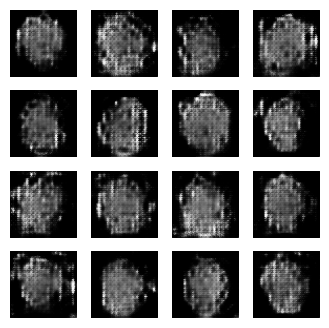

In [ ]:
def generate_images(model, n=16):
    #Generates and displays a grid of fake images from the generator
    noise = tf.random.normal([n, noise_dim])
    #Create 'n' random noise vectors as input to the generator
    imgs = model(noise, training=False)
    #Generate images from the noise; training=False disables layers like dropout

    plt.figure(figsize=(4,4))
    #Create a 4x4 inch figure to display images
    for i in range(n):
        plt.subplot(4,4,i+1)
        #Create a subplot for each image in a 4x4 grid
        plt.imshow(imgs[i,:,:,0]*127.5 + 127.5, cmap="gray")
        #Scale pixel values from [-1,1] back to [0,255] and display as grayscale
        plt.axis("off")
        #Hide axes for a cleaner look
    plt.show()
    #Display all images

generate_images(generator)
#Call the function to generate and show images using the trained generator

STEP 11 — Save Models

In [ ]:
# STEP 11: Save models

generator.save("gan_generator_model.h5")
discriminator.save("gan_discriminator_model.h5")